# LOS Bolometry Surrogate Data Frame (Standalone)

Generate (emissivity, measurements) pairs using the forward model only.
Geometry is fixed; this is **not** a GA workflow.


In [1]:
import numpy as np

from indica.defaults.load_defaults import load_default_objects
from indica.models import PinholeCamera
from indica.operators.atomic_data import default_atomic_data
from los_bolometry_geometry import origin_from_polar_angle, direction_from_polar_and_dir_offset,update_los
import matplotlib.pyplot as plt

In [2]:
# Basic setup (lifted from the beginning of run_example_diagnostic_model)
machine = "st40"
instrument = "blom_xy1"

# Initialise plasma and diagnostic model
transforms = load_default_objects(machine, "geometry")
equilibrium = load_default_objects(machine, "equilibrium")
plasma = load_default_objects(machine, "plasma")

plasma.set_equilibrium(equilibrium)
transform = transforms[instrument]
transform.set_equilibrium(equilibrium)
transform.spot_shape = "square"
transform.focal_length = -1000.0

# Model setup
_, power_loss = default_atomic_data(["h", "ar", "c", "he"])
model = PinholeCamera(instrument, power_loss=power_loss)
model.set_transform(transform)
model.set_plasma(plasma)

# TODO: change plasma here if you want to sample a different emissivity field
# Example: plasma.<...> = <...>


## Chosen frozen sensor geometry

/home/jussi.hakosalo/.conda/envs/jussitestindica311/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:2001: UserWarning: The following kwargs were not used by contour: 'linestyle'
  primitive = ax.contour(x, y, z, **kwargs)


Previewed LOS geometry for pulse 13622 (blom_xy1)


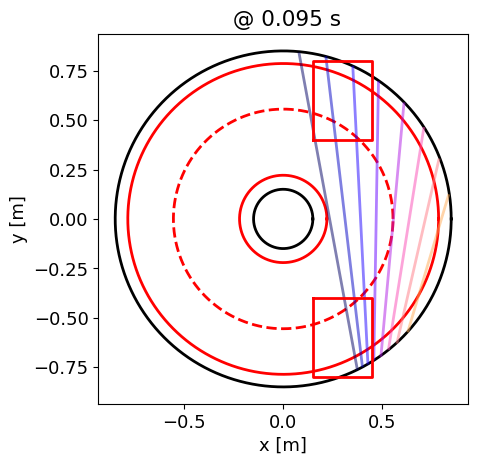

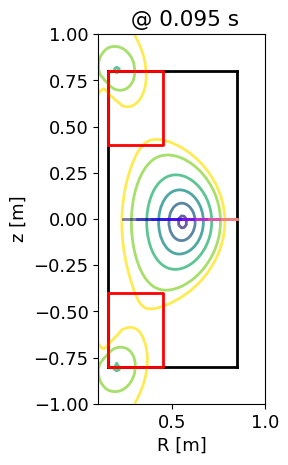

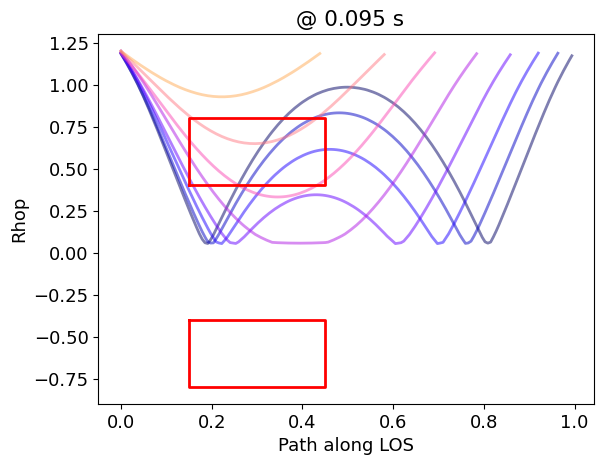

In [3]:

from indica import Equilibrium
from indica.readers import ST40Reader

# Preview LOS geometry from a real pulse.
# This cell is for visualization only and does not set/overwrite `individual`.
preview_pulse = 13622
preview_tstart = 0.04
preview_tend = 0.15
preview_dt = 0.01

preview_reader = ST40Reader(
    preview_pulse,
    preview_tstart - preview_dt,
    preview_tend + preview_dt,
    dt=preview_dt,
    verbose=False,
)
preview_equilibrium_data = preview_reader.get("", "efit", 0)
preview_equilibrium = Equilibrium(preview_equilibrium_data)

preview_instrument_data = preview_reader.get("", instrument, 0)
preview_quantity = next(iter(preview_instrument_data))
preview_transform = preview_instrument_data[preview_quantity].attrs["transform"]
preview_transform.set_equilibrium(preview_equilibrium, force=True)

update_los(preview_transform)
preview_transform.plot()
print(f"Previewed LOS geometry for pulse {preview_pulse} ({instrument})")


## Plasma generator

In [4]:
from indica.workflows.plasma_profiler_init import load_bda_config, build_plasma_profiler, sample_prior_parameters

class PlasmaGenerator():
    def __init__(self, model,transform,config_name="ion_temperature_phantom_run_all_params"):
        self.model = model
        self.transform = transform
        self.cfg = load_bda_config(
            config_name="ion_temperature_phantom_run_all_params",
            overrides=[
                "plasma.settings.n_rad=41",
                "tstart=0.04",
                "tend=0.15",
                "dt=0.01",
            ],
            )
        self.plasma_profiler = build_plasma_profiler(self.cfg)

    def generate(self):
        all_params = sample_prior_parameters(self.cfg)
        self.plasma_profiler(all_params)
        return self.plasma_profiler.plasma
    
    def run_model(self,target_plasma=None):
        if target_plasma is not None:
            self.model.set_plasma(target_plasma)
        else:
            self.model.set_plasma(self.plasma_profiler.plasma)
            
        self.model.set_transform(self.transform)
        bckc, emissivity = self.model(return_emissivity=True)
        measurements = bckc["brightness"]
        return(measurements, emissivity)

    
    



## Data generation and writing

In [5]:
#Generate all the pairs of (emissivity, measurements) for the given plasma. 
#No temporal relations, each time step is independent for now.
b_slices=[]
eps_slices=[]
generate_new_data=False
b_dir="jussitesting/vae_firstpass/b_slices.csv"
eps_dir="jussitesting/vae_firstpass/eps_slices.csv"
if generate_new_data:
    
    import csv
    generator=PlasmaGenerator(model,transform)
    use_all_timepoints = False  # Set True when generator has meaningful time dynamics.
    for r in range(4000):
        if not r%200:
            print(f"Elapsed: {r}/2000")
        generator.generate()
        measurements, emissivity = generator.run_model()
        if use_all_timepoints:
            t_indices = range(measurements.sizes["t"])
        else:
            #If random index
            t_indices = [np.random.randint(measurements.sizes["t"])]
            #Central index
            #t_indices=[int(measurements.sizes["t"]/2)]
        for t_idx in t_indices:
            channel_vector = measurements.isel(t=t_idx).values.astype(np.float32)
            emissivity_slice = emissivity.isel(t=t_idx).values.astype(np.float32)
            b_slices.append(channel_vector)
            eps_slices.append(emissivity_slice)
    print(len(b_slices), len(eps_slices))
    b_slices=np.array(b_slices)
    eps_slices=np.array(eps_slices)
    print(b_slices.shape, eps_slices.shape)



    with open(b_dir, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(b_slices)
    with open(eps_dir, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(eps_slices)

        

## FIlter pulses

In [9]:
from indica.readers.st40_pulse_filtering import filter_pulses
import pickle
r_start=13500
r_end=14000
create_valids=False
if create_valids:
    valids, invalids=filter_pulses(range(r_start,r_end))
    print(len(valids))
    with open(f'valids_range_{r_start}_{r_end}.pkl', 'wb') as f:
        pickle.dump(valids,f)
else:
    with open(f'valids_range_{r_start}_{r_end}.pkl', 'rb') as f:
        valids=pickle.load(f)
        print(len(valids))



272


In [10]:
# Multi-pulse real-data dataset generation (ST40Reader-based)
# Builds (measurements, emissivity) pairs like the cell above, but scans a pulse range.
import csv

from indica import Equilibrium
from indica.examples.example_plasma import example_plasma
from indica.models import PinholeCamera
from indica.operators.atomic_data import default_atomic_data
from indica.readers import ST40Reader

machine = 'st40'
instrument = 'blom_xy1'
tstart = 0.04
tend = 0.15
dt = 0.01
filtered_pulses=valids
use_all_timepoints = True

b_dir = 'jussitesting/vae_firstpass/b_slices_multipulse.csv'
eps_dir = 'jussitesting/vae_firstpass/eps_slices_multipulse.csv'
meta_dir = 'jussitesting/vae_firstpass/sample_meta_multipulse.csv'

b_slices = []
eps_slices = []
sample_meta = []

_, power_loss = default_atomic_data(['h', 'ar', 'c', 'he'])

def build_real_model_for_pulse(pulse: int):
    reader = ST40Reader(pulse, tstart - dt, tend + dt, dt=dt, verbose=False)

    equilibrium_data = reader.get('', 'efit', 0)
    equilibrium = Equilibrium(equilibrium_data)

    plasma = example_plasma(
        machine=machine,
        tstart=tstart,
        tend=tend,
        dt=dt,
        main_ion='h',
        impurities=('c', 'ar', 'he'),
        full_run=False,
        n_rad=41,
        n_R=100,
        n_z=100,
    )
    plasma.set_equilibrium(equilibrium)

    # Seed plasma profiles from measured fitted profiles on rhop
    ppts = reader.get('', 'ppts', 0)
    plasma.electron_density.loc[dict(t=plasma.t)] = (
        ppts['ne_rhop'].interp(t=plasma.t, rhop=plasma.rhop).transpose('t', 'rhop').values
    )
    plasma.electron_temperature.loc[dict(t=plasma.t)] = (
        ppts['te_rhop'].interp(t=plasma.t, rhop=plasma.rhop).transpose('t', 'rhop').values
    )

    instrument_data = reader.get('', instrument, 0)
    first_quantity = next(iter(instrument_data))
    transform = instrument_data[first_quantity].attrs['transform']
    transform.set_equilibrium(equilibrium, force=True)
    transform.spot_shape = 'square'
    transform.focal_length = -1000.0
    """
    # Reapply frozen LOS layout if the 'individual' vector is available in the notebook
    if 'individual' in globals():
        indiv = individual
        N = len(indiv) // 2
        los_angles = indiv[:N]
        offsets = indiv[N:]
        directions = []
        origins = []
        for i in range(N):
            new_origin_x, new_origin_z = origin_from_polar_angle(los_angles[i], transform)
            origins.append((new_origin_x, 0, new_origin_z))
            new_dir_x, new_dir_z = direction_from_polar_and_dir_offset(
                los_angles[i], offsets[i], transform
            )
            directions.append((new_dir_x, 0, new_dir_z))
        transform.set_origin(np.array(origins))
        transform.set_direction(np.array(directions))
        update_los(transform)
    """

    model = PinholeCamera(instrument, power_loss=power_loss)
    model.set_transform(transform)
    model.set_plasma(plasma)
    return model

for pulse in filtered_pulses:
    try:
        model_pulse = build_real_model_for_pulse(pulse)
        bckc, emissivity = model_pulse(return_emissivity=True)
        measurements = bckc['brightness']

        if use_all_timepoints:
            t_indices = range(measurements.sizes['t'])
        else:
            t_indices = [np.random.randint(measurements.sizes['t'])]

        for t_idx in t_indices:
            channel_vector = measurements.isel(t=t_idx).values.astype(np.float32)
            emissivity_slice = emissivity.isel(t=t_idx).values.astype(np.float32)
            b_slices.append(channel_vector)
            eps_slices.append(emissivity_slice)
            sample_meta.append((pulse, float(measurements.t.isel(t=t_idx).values)))

        print(f'Pulse {pulse}: added {len(list(t_indices))} samples')
    except Exception as exc:
        print(f'Skipping pulse {pulse}: {exc}')

b_slices = np.array(b_slices, dtype=np.float32)
eps_slices = np.array(eps_slices, dtype=np.float32)
print('Final shapes:', b_slices.shape, eps_slices.shape)

with open(b_dir, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(b_slices)
with open(eps_dir, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(eps_slices)
with open(meta_dir, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['pulse', 'time_s'])
    writer.writerows(sample_meta)

print(f'Wrote: {b_dir}, {eps_dir}, {meta_dir}')


no profile params given so updating all
Skipping pulse 13500: 'R_data'
no profile params given so updating all
Pulse 13501: added 12 samples
no profile params given so updating all
Pulse 13509: added 12 samples
no profile params given so updating all
Pulse 13510: added 12 samples
no profile params given so updating all
Pulse 13511: added 12 samples
no profile params given so updating all
Skipping pulse 13512: numpy.nanmin raises on a.size==0 and axis=None; So Bottleneck too.
no profile params given so updating all
Pulse 13513: added 12 samples
Skipping pulse 13519: 'rbnd'
Skipping pulse 13520: 'rbnd'
Skipping pulse 13521: 'rbnd'
Skipping pulse 13522: 'rbnd'
Skipping pulse 13523: 'rbnd'
Skipping pulse 13524: 'rbnd'
Skipping pulse 13525: 'rbnd'
Skipping pulse 13526: 'rbnd'
Skipping pulse 13527: 'rbnd'
Skipping pulse 13528: 'rbnd'
Skipping pulse 13529: 'rbnd'
Skipping pulse 13530: 'rbnd'
no profile params given so updating all
Pulse 13537: added 12 samples
no profile params given so updat

In [13]:
# Remove zero-heavier (measurement, emissivity) pairs from the same CSV files.
import csv
import numpy as np
b_slices = np.loadtxt(b_dir, delimiter=',', dtype=np.float32)
eps_slices = np.loadtxt(eps_dir, delimiter=',', dtype=np.float32)

if b_slices.ndim == 1:
    b_slices = b_slices[None, :]
if eps_slices.ndim == 1:
    eps_slices = eps_slices[None, :]

if len(b_slices) != len(eps_slices):
    raise ValueError('b_dir and eps_dir must contain the same number of samples')

zero_counts = (
    np.count_nonzero(b_slices == 0.0, axis=1)
    + np.count_nonzero(eps_slices == 0.0, axis=1)
)
min_zero_count = int(zero_counts.min())+30
keep_mask = zero_counts <= min_zero_count

b_filtered = b_slices[keep_mask]
eps_filtered = eps_slices[keep_mask]

with open(b_dir, 'w', newline='') as f:
    csv.writer(f).writerows(b_filtered)
with open(eps_dir, 'w', newline='') as f:
    csv.writer(f).writerows(eps_filtered)

if 'meta_dir' in globals():
    try:
        with open(meta_dir, newline='') as f:
            rows = list(csv.reader(f))
        has_header = bool(rows) and rows[0] == ['pulse', 'time_s']
        header = rows[0] if has_header else None
        data_rows = rows[1:] if has_header else rows
        if len(data_rows) == len(keep_mask):
            filtered_meta = [row for row, keep in zip(data_rows, keep_mask) if keep]
            with open(meta_dir, 'w', newline='') as f:
                writer = csv.writer(f)
                if header is not None:
                    writer.writerow(header)
                writer.writerows(filtered_meta)
            print(f'Updated meta file: {meta_dir}')
        else:
            print('meta_dir row count did not match sample count; left meta file unchanged')
    except FileNotFoundError:
        print(f'meta file not found: {meta_dir}')

print(
    f'Kept {int(keep_mask.sum())} / {len(keep_mask)} pairs (removed {int((~keep_mask).sum())}); '
    f'min zero-count was {min_zero_count}'
)


Updated meta file: jussitesting/vae_firstpass/sample_meta_multipulse.csv
Kept 1217 / 2592 pairs (removed 1375); min zero-count was 30


In [29]:
# In-memory strict filter: drop pairs that would fail tomography channel validation.
# This does NOT write anything back to CSV files.
if 'b_filtered' in globals() and 'eps_filtered' in globals():
    b_work = b_filtered.astype(np.float32, copy=False)
    eps_work = eps_filtered.astype(np.float32, copy=False)
else:
    b_work = np.loadtxt(b_dir, delimiter=',', dtype=np.float32)
    eps_work = np.loadtxt(eps_dir, delimiter=',', dtype=np.float32)
    if b_work.ndim == 1:
        b_work = b_work[None, :]
    if eps_work.ndim == 1:
        eps_work = eps_work[None, :]
    if len(b_work) != len(eps_work):
        raise ValueError('b_dir and eps_dir must contain the same number of samples')

# Tomography keeps channels where brightness is finite and strictly > 0.
# A sample fails if it has no valid channels.
min_valid_channels_required = 1
valid_channels = np.isfinite(b_work) & (b_work > 0.0)
n_valid_channels = valid_channels.sum(axis=1)
keep_mask_tomo = n_valid_channels >= min_valid_channels_required

b_runtime = b_work[keep_mask_tomo]
eps_runtime = eps_work[keep_mask_tomo]

meta_runtime = None
if 'meta_dir' in globals():
    try:
        with open(meta_dir, newline='') as f:
            rows = list(csv.reader(f))
        has_header = bool(rows) and rows[0] == ['pulse', 'time_s']
        data_rows = rows[1:] if has_header else rows
        if len(data_rows) == len(keep_mask_tomo):
            meta_runtime = [row for row, keep in zip(data_rows, keep_mask_tomo) if keep]
        else:
            print('meta_dir row count did not match sample count for strict in-memory filter')
    except FileNotFoundError:
        print(f'meta file not found: {meta_dir}')

print(
    f'Strict in-memory filter kept {int(keep_mask_tomo.sum())} / {len(keep_mask_tomo)} pairs '
    f'(removed {int((~keep_mask_tomo).sum())}) with min_valid_channels_required={min_valid_channels_required}'
)
print('In-memory arrays ready: b_runtime, eps_runtime, meta_runtime')


Strict in-memory filter kept 1217 / 1217 pairs (removed 0) with min_valid_channels_required=1
In-memory arrays ready: b_runtime, eps_runtime, meta_runtime


## Dataset creation


In [30]:

import csv
import os

from torch.utils.data import Dataset, DataLoader
import torch

class PairDataset(Dataset):
    def __init__(self, b_dir, eps_dir, meta_dir=None, zero_tol=0.0):
        self.b_dir = b_dir
        self.eps_dir = eps_dir
        self.meta_dir = meta_dir
        self.zero_tol = float(zero_tol)
        self.b_slices = np.loadtxt(b_dir, delimiter=',', dtype=np.float32)
        self.eps_slices = np.loadtxt(eps_dir, delimiter=',', dtype=np.float32)
        if self.b_slices.ndim == 1:
            self.b_slices = self.b_slices[None, :]
        if self.eps_slices.ndim == 1:
            self.eps_slices = self.eps_slices[None, :]
        if len(self.b_slices) != len(self.eps_slices):
            raise ValueError('b_dir and eps_dir must contain the same number of samples')

        self.mu_b, self.sigma_b = np.mean(self.b_slices), np.std(self.b_slices)
        self.mu_eps, self.sigma_eps = np.mean(self.eps_slices), np.std(self.eps_slices)

        b_zeros = np.count_nonzero(np.abs(self.b_slices) <= self.zero_tol, axis=1)
        eps_zeros = np.count_nonzero(np.abs(self.eps_slices) <= self.zero_tol, axis=1)
        total_dims = self.b_slices.shape[1] + self.eps_slices.shape[1]
        self.sample_nonzero_fraction = 1.0 - (b_zeros + eps_zeros) / total_dims

        self.pulse_quality = {}
        self.best_pulse = None
        if meta_dir is not None and os.path.exists(meta_dir):
            with open(meta_dir, newline='') as f:
                rows = list(csv.reader(f))
            has_header = bool(rows) and rows[0] == ['pulse', 'time_s']
            data_rows = rows[1:] if has_header else rows
            if len(data_rows) == len(self.sample_nonzero_fraction):
                pulse_to_scores = {}
                for row, score in zip(data_rows, self.sample_nonzero_fraction):
                    pulse = int(float(row[0]))
                    pulse_to_scores.setdefault(pulse, []).append(float(score))
                self.pulse_quality = {
                    pulse: float(np.mean(scores)) for pulse, scores in pulse_to_scores.items()
                }
                if self.pulse_quality:
                    self.best_pulse = max(self.pulse_quality, key=self.pulse_quality.get)

    def get_top_pulses(self, n=5, min_nonzero_fraction=0.0):
        if not self.pulse_quality:
            return []
        return [
            (pulse, score)
            for pulse, score in sorted(
                self.pulse_quality.items(), key=lambda x: x[1], reverse=True
            )
            if score >= min_nonzero_fraction
        ][:n]


    def __len__(self):
        return len(self.b_slices)
    
    def __getitem__(self, idx):
        b_slice = self.b_slices[idx]
        eps_slice = self.eps_slices[idx]
        return(eps_slice-self.mu_eps)/self.sigma_eps,(b_slice-self.mu_b)/self.sigma_b

In [31]:
dataset = PairDataset(b_dir, eps_dir, meta_dir=meta_dir if 'meta_dir' in globals() else None)
if dataset.best_pulse is not None:
    best_score = dataset.pulse_quality[dataset.best_pulse]
    print(f'Best pulse by mean nonzero fraction: {dataset.best_pulse} ({best_score:.3f})')
    print('Top 20 pulses:', dataset.get_top_pulses(n=20))
else:
    print('Pulse-level quality unavailable (missing/unmatched meta_dir).')

trainsplit, testsplit=torch.utils.data.random_split(dataset, lengths=[int(0.8*len(dataset)), len(dataset) - int(0.8*len(dataset))])

train_dataloader=DataLoader(trainsplit, batch_size=8, shuffle=True)
test_dataloader=DataLoader(testsplit, batch_size=8, shuffle=True)

print(len(train_dataloader))

Best pulse by mean nonzero fraction: 13509 (1.000)
Top 20 pulses: [(13509, 1.0), (13537, 1.0), (13540, 1.0), (13550, 1.0), (13586, 1.0), (13589, 1.0), (13618, 1.0), (13619, 1.0), (13620, 1.0), (13624, 1.0), (13625, 1.0), (13627, 1.0), (13628, 1.0), (13631, 1.0), (13640, 1.0), (13643, 1.0), (13658, 1.0), (13659, 1.0), (13661, 1.0), (13662, 1.0)]
122


## Sanity check

#### Notation
- $p_\theta$ denotes a generative model, parameterized by $\theta$
- $q_\phi$ denotes the variational approximation (encoder), parametrized by $\phi$ 
- In variational bayes, p is true model and q approximating dist. Also phi is inference parameter and theta generative parameter.


#### Currently we have:
- A collection of (8,) shaped bolometer signals $b$, each one is from a different time slice-> right now, consider time independent
- A matching collection of (41,) shaped emissivity signals $e$, same thing.
- We have a torch dataset defined for this, and this dataset has normalisation coefficients computed. Scale when we  call getitem.

#### Conceptual model definiton - dummy edition

Three random variables:
1) Emissivity $e \in \real^{41}$. What we observe during training, this is what the model targets.
2) Latent variable $z \in \real^{d}$. Unobserved.
3) Bolometry $b \in \real^{8}$. Observed and conditioned on. 

ie. Given $b$, sample $z$, then generate $e$.

#### Decoder 

1) Draw a latent variable from a standard normal: $Z \sim \mathcal{N}(0,I)$ 
2) Given a bolometer measurement $b$ and a latent variable $z$, the emissivity follows a distribution parametrized by the decoder network:  $e | (b,z) \sim p_{\theta}(e | b,z)$
3) When conditioned on $b$ and $z$, the emissivity follows a Gaussian whose mean is predicted by the decoder network, covariance is identity ie. decoder only predicts the mean emissivity, all remaining uncertainty is represented by $z$ ie.  $p_{\theta}(e | b,z) = \mathcal{N}(\mu_\theta (b,z),I)$.

#### Encoder
1) The approximate posterior over $z$, conditioned on both $e$ and $b$, $q_{\phi}(z|e,b)$, $= \mathcal{N}(\mu_z (e,b), diag (\sigma^2_z (e,b)))$. The encoder takes emissivity and bolometer inputs, and outputs mean and variacne of a Gaussian over $z$.
2) This is same as saying "which latent variables could have plausibly produced the observed emissivity, when combined with the bolometry?"

#### Training

1) We take an emissivity and bolometry inputs and then when given into the encoder, the encoder gives the Gaussian parameters for the latent variable as: $(\mu_z,\sigma_z) =Encoder(e,b)$
2) Sample the latent by adding gaussian noise to encoder mean scaled with the predicted sd: $z=\mu_z+\sigma_z \odot \epsilon, \epsilon \sim \mathcal{N}(0,I)$. 
3) Last step used reparametrization trick. Since Z is sampled, and sampling is not differentiable, gradients cannot flow through a random draw. Instead of sampling from the gaussian whose params I am trying to learn, I take standard noise and transform this using the params I wanna learn. This becomes differentiable and gradients can flow through!
4) Decode: decoder takes bolometer measurement and sampled latent, and outputs a predicted emissivity profile $\hat{e}=\mu_\theta (b,z)$


#### Loss
1) Reconstruction term, square difference between true emissivity and predicted: $||e-\hat{e}||^2$. We assume Gaussian with unit variance for decoder, so squared error is proportional to negative log-likelihood of true emissivity under the model. DO the math! 
2) KL-divegence term: Measures how different the encoders inferred latent dist is from a standard noraml. Basically, this means the encoder has to use the bolometer as well and not just try to hide everything behind the latent variables:
$KL(q_\phi (z|e,b) || \mathcal{N}(0,I))$

3) The combined loss: model is trained to reconstruct the observed emissivity and keep the latent variables close to a Gaussian. $\mathcal{L} = \mathbb{E}_{q_\theta (z|e,b)}[||e-\hat{e}||^2]+KL(q_\phi (z|e,b) || \mathcal{N}(0,I))$. ANother wording: First loss term is the squared recosnstruction error in the emissivity, when expectation is taken wrt the approximate posterior over the latent variables and standard normal prior.


Basically: 


#### Inference time
1) Encoder is not used
2) Sample from latent, and let decoder figure what the emissivity would be based on that.

## cVAE structure and training

In [32]:
#Note that encoder takes in 41+6! I changed dataloader order.
from torch import nn
import torch

latent_dim=4


class Network(nn.Module):
    def __init__(self, input_dim=49, latent_dim=4):
        super(Network, self).__init__()
        self.fc1m = nn.Linear(input_dim, 64)
        self.fc1s = nn.Linear(input_dim, 64)

        self.fc2m = nn.Linear(64, 32)
        self.fc2s = nn.Linear(64, 32)
        
        self.fc3m = nn.Linear(32, latent_dim)
        self.fc3s = nn.Linear(32, latent_dim)



        self.fc_dec1 = nn.Linear(latent_dim + 8, 32)
        self.fc_dec2 = nn.Linear(32, 64)
        self.fc_dec3 = nn.Linear(64, 41)
    #encode
    def encode(self, emis, bolom ):
        x = torch.cat((emis, bolom), dim=1)

        m = torch.relu(self.fc1m(x))
        logvar = torch.relu(self.fc1s(x))

        m = torch.relu(self.fc2m(m))
        logvar = torch.relu(self.fc2s(logvar))
        
        m = self.fc3m(m)
        logvar = self.fc3s(logvar)
        return m, logvar
    
    def decode(self, b,z):
        x=torch.cat((b,z), dim=1)
        x = torch.relu(self.fc_dec1(x))
        x = torch.relu(self.fc_dec2(x))
        x = self.fc_dec3(x)
        return x

    def reparametrize(self,m, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return m + eps * std
    
    def KL_divergence(self, m, logvar):
        return -0.5 * torch.sum(1 + logvar - m.pow(2) - logvar.exp(), dim=1)
    
    def total_loss(self, recon_x, x, m, logvar, return_components=False, kl_beta=0):
        recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
        kl_loss = self.KL_divergence(m, logvar).sum()
        #print("Recon mean: ", recon_loss.item()/x.shape[0], "KL mean: ", kl_loss.item()/x.shape[0])
        total = (recon_loss + kl_beta * kl_loss) / x.shape[0]
        if return_components:
            return total, recon_loss / x.shape[0], kl_loss*kl_beta / x.shape[0]
        return total
    

    def forward(self, emis, bolom):
        m, logvar = self.encode(emis, bolom)
        z = self.reparametrize(m, logvar)
        e_hat = self.decode(bolom, z)
        return e_hat, m, logvar, z
    

def train(model, epoch, optimizer, n_epochs=30):
    model.train()
    train_loss = 0
    recon_loss_total = 0
    kl_loss_total = 0
    kl_epoch_beta = (epoch / n_epochs)*0.5
    for batch_idx, (emis, bolom) in enumerate(train_dataloader):
        optimizer.zero_grad()
        recon_emis, m, logvar, z = model(emis, bolom)
        loss,rec,kl = model.total_loss(recon_emis, emis, m, logvar, return_components=True,kl_beta=kl_epoch_beta)
        loss.backward()
        train_loss += loss.item()
        recon_loss_total += rec.item()
        kl_loss_total += kl.item()
        optimizer.step()
    print(f'====> Epoch: {epoch} Average loss: {train_loss/len(train_dataloader):.4f}')
    print(f'====> Epoch: {epoch} Average recon loss: {recon_loss_total/len(train_dataloader):.4f} Average KL loss: {kl_loss_total/len(train_dataloader):.4f}')
    
vaemodel=Network(latent_dim=latent_dim)
total_params = sum(p.numel() for p in vaemodel.parameters())
print(f"Total number of parameters in the VAE model: {total_params}")
optimizer=torch.optim.Adam(vaemodel.parameters(), lr=1e-3)
n_epochs=25
for epoch in range(1, n_epochs): 
    train(vaemodel,epoch,optimizer,n_epochs=n_epochs)

Total number of parameters in the VAE model: 16017
====> Epoch: 1 Average loss: 13.2978
====> Epoch: 1 Average recon loss: 13.1108 Average KL loss: 0.1870
====> Epoch: 2 Average loss: 1.8960
====> Epoch: 2 Average recon loss: 1.4663 Average KL loss: 0.4297
====> Epoch: 3 Average loss: 1.2357
====> Epoch: 3 Average recon loss: 0.8417 Average KL loss: 0.3940
====> Epoch: 4 Average loss: 1.0368
====> Epoch: 4 Average recon loss: 0.6465 Average KL loss: 0.3902
====> Epoch: 5 Average loss: 1.0304
====> Epoch: 5 Average recon loss: 0.6368 Average KL loss: 0.3936
====> Epoch: 6 Average loss: 0.8942
====> Epoch: 6 Average recon loss: 0.4854 Average KL loss: 0.4088
====> Epoch: 7 Average loss: 0.8770
====> Epoch: 7 Average recon loss: 0.4563 Average KL loss: 0.4207
====> Epoch: 8 Average loss: 0.9074
====> Epoch: 8 Average recon loss: 0.4442 Average KL loss: 0.4632
====> Epoch: 9 Average loss: 0.9388
====> Epoch: 9 Average recon loss: 0.4599 Average KL loss: 0.4788
====> Epoch: 10 Average loss:

## Sanity checks: diversity and fw consistency metrics: one set of values and intuition



### Conditional sampling diversity
- Mean L2 distance to sample-mean : 0.057555 -> Average spread of the posterior ie. how far are samples from the posterior mean? How concentrated is my posterior?
- Max per-dim std: 0.103400  -> In regions where the uncertainty is the strongest, how strong is it?
- L2(sample-mean, true e): 0.061272 -> Bias of the posterior mean. Is posterior centered correctly around the true value?


### Forward consistency

- Mean L2: 0.095481 -> Are the sampled emissivities consistent with the conditioning measurement? If large, posterior samples do not adhere to the bolometry measurement conditioning.
- Max abs error : 0.213974 -> Largest single bolometer channel inconsistency. Fw model measurements vs the actual measurements!

In [33]:
import torch

vaemodel.eval()

K = 100
idx = 10  

# Single example from the dataset
test_dataset = test_dataloader.dataset
e_true, b_star = test_dataset[idx]          
e_true = torch.from_numpy(e_true).unsqueeze(0)                
b_star = torch.from_numpy(b_star).unsqueeze(0)                

#Latent dim
latent_dim = vaemodel.fc3m.out_features

with torch.no_grad():
    # Sample K latents
    z = torch.randn(K, latent_dim)           
    # Repeat b* K times
    b_rep = b_star.expand(K, -1)                            

    # Decode K samples
    e_samps = vaemodel.decode(b_rep, z)                     

#  Use the same dataset object for stats. It has mu and sigma for unnormalization.
subset=test_dataloader.dataset
dataset=subset.dataset

#Diversity metrics


with torch.no_grad():
    #unnormalize samples and true value
    e_samps_un = e_samps * dataset.sigma_eps + dataset.mu_eps
    e_true_un  = e_true  * dataset.sigma_eps + dataset.mu_eps

    e_mean_un = e_samps_un.mean(dim=0, keepdim=True)        
    l2_to_mean = torch.norm(e_samps_un - e_mean_un, dim=1)  
    mean_l2 = l2_to_mean.mean().item()

    std_per_dim = e_samps_un.std(dim=0)                     # (41,)
    mean_std = std_per_dim.mean().item()
    max_std  = std_per_dim.max().item()

    e_scale = torch.norm(e_true_un, dim=1).item() + 1e-8
    mean_l2_norm  = mean_l2 / e_scale
    mean_std_norm = mean_std / (e_scale / (e_true_un.shape[1] ** 0.5))
    max_std_norm  = max_std  / (e_scale / (e_true_un.shape[1] ** 0.5))

print("Conditional sampling diversity")
print(f"K = {K}, idx = {idx}")
print(f"Mean L2 distance to sample-mean (norm): {mean_l2_norm:.6f}")
print(f"Mean per-dim std (norm): {mean_std_norm:.6f}")
print(f"Max  per-dim std (norm): {max_std_norm:.6f}")

err_to_true = torch.norm(e_mean_un - e_true_un, dim=1).item()
print(f"L2(sample-mean, true e) (norm): {(err_to_true / e_scale):.6f}")

# FW consistency metrics
e_all = torch.as_tensor(dataset.eps_slices)  # (N,41) unnormalized
b_all = torch.as_tensor(dataset.b_slices)   # (N,6)  unnormalized
A = torch.linalg.lstsq(e_all, b_all).solution               # (41,6)

with torch.no_grad():
    b_star_un = b_star * dataset.sigma_b + dataset.mu_b
    b_hat = e_samps_un @ A
    diff = b_hat - b_star_un

    l2 = torch.norm(diff, dim=1)
    mean_l2 = l2.mean().item()
    rmse = torch.sqrt((diff ** 2).mean()).item()
    max_abs = diff.abs().max().item()

    b_scale = torch.norm(b_star_un, dim=1).item() + 1e-8
    mean_l2_norm = mean_l2 / b_scale
    rmse_norm = rmse / (b_scale / (b_star_un.shape[1] ** 0.5))
    max_abs_norm = max_abs / (b_scale / (b_star_un.shape[1] ** 0.5))

print("Forward consistency (linear surrogate)")
print(f"Mean L2(b_hat, b*): {mean_l2_norm:.6f}")
print(f"RMSE : {rmse_norm:.6f}")
print(f"Max abs error : {max_abs_norm:.6f}")



Conditional sampling diversity
K = 100, idx = 10
Mean L2 distance to sample-mean (norm): 0.137013
Mean per-dim std (norm): 0.095987
Max  per-dim std (norm): 0.576920
L2(sample-mean, true e) (norm): 0.132820
Forward consistency (linear surrogate)
Mean L2(b_hat, b*): 0.165058
RMSE : 0.167592
Max abs error : 0.436972


## Good plasmas to visualise with (not working atm)

In [41]:
visualsation_pulses=[(13509, 1.0), (13537, 1.0), (13662, 1.0), (13540, 1.0), (13586, 1.0), (13589, 1.0), (13618, 1.0), (13619, 1.0), (13620, 1.0), (13624, 1.0), (13625, 1.0), (13627, 1.0), (13628, 1.0), (13631, 1.0), (13640, 1.0), (13643, 1.0), (13658, 1.0), (13659, 1.0), (13661, 1.0), (13662, 1.0)]


no profile params given so updating all
Using pulse 13509
emissivity shape: (12, 41)
brightness shape: (12, 8)
Candidate time indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Valid channels per t: [0, 0, 0, 8, 8, 8, 8, 8, 8, 8, 8, 8]
Kept time indices for tomography: [3, 4, 5, 6, 7, 8, 9, 10, 11]
no profile params given so updating all
Using pulse 13537
emissivity shape: (12, 41)
brightness shape: (12, 8)
Candidate time indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Valid channels per t: [0, 0, 0, 8, 8, 8, 8, 8, 8, 8, 8, 8]
Kept time indices for tomography: [3, 4, 5, 6, 7, 8, 9, 10, 11]
no profile params given so updating all
Using pulse 13662
emissivity shape: (12, 41)
brightness shape: (12, 8)
Candidate time indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Valid channels per t: [0, 0, 0, 0, 8, 8, 8, 8, 8, 8, 8, 5]
Kept time indices for tomography: [4, 5, 6, 7, 8, 9, 10, 11]
Plotted 3 pulse(s).


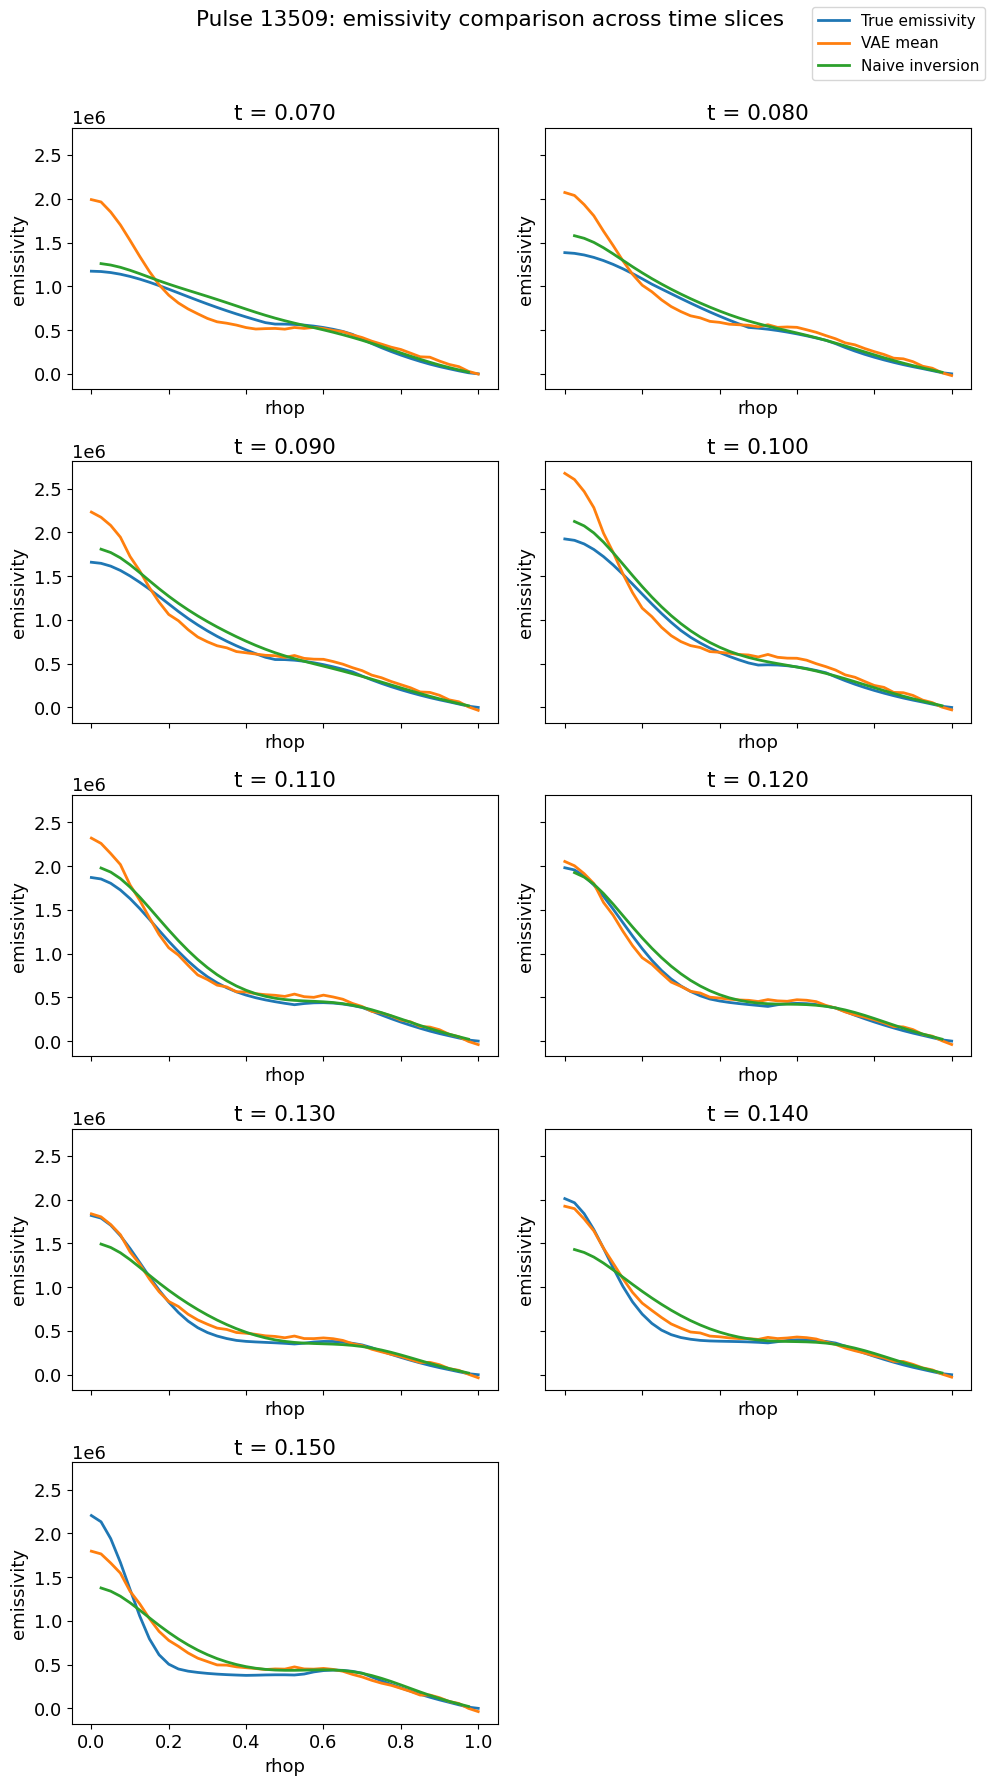

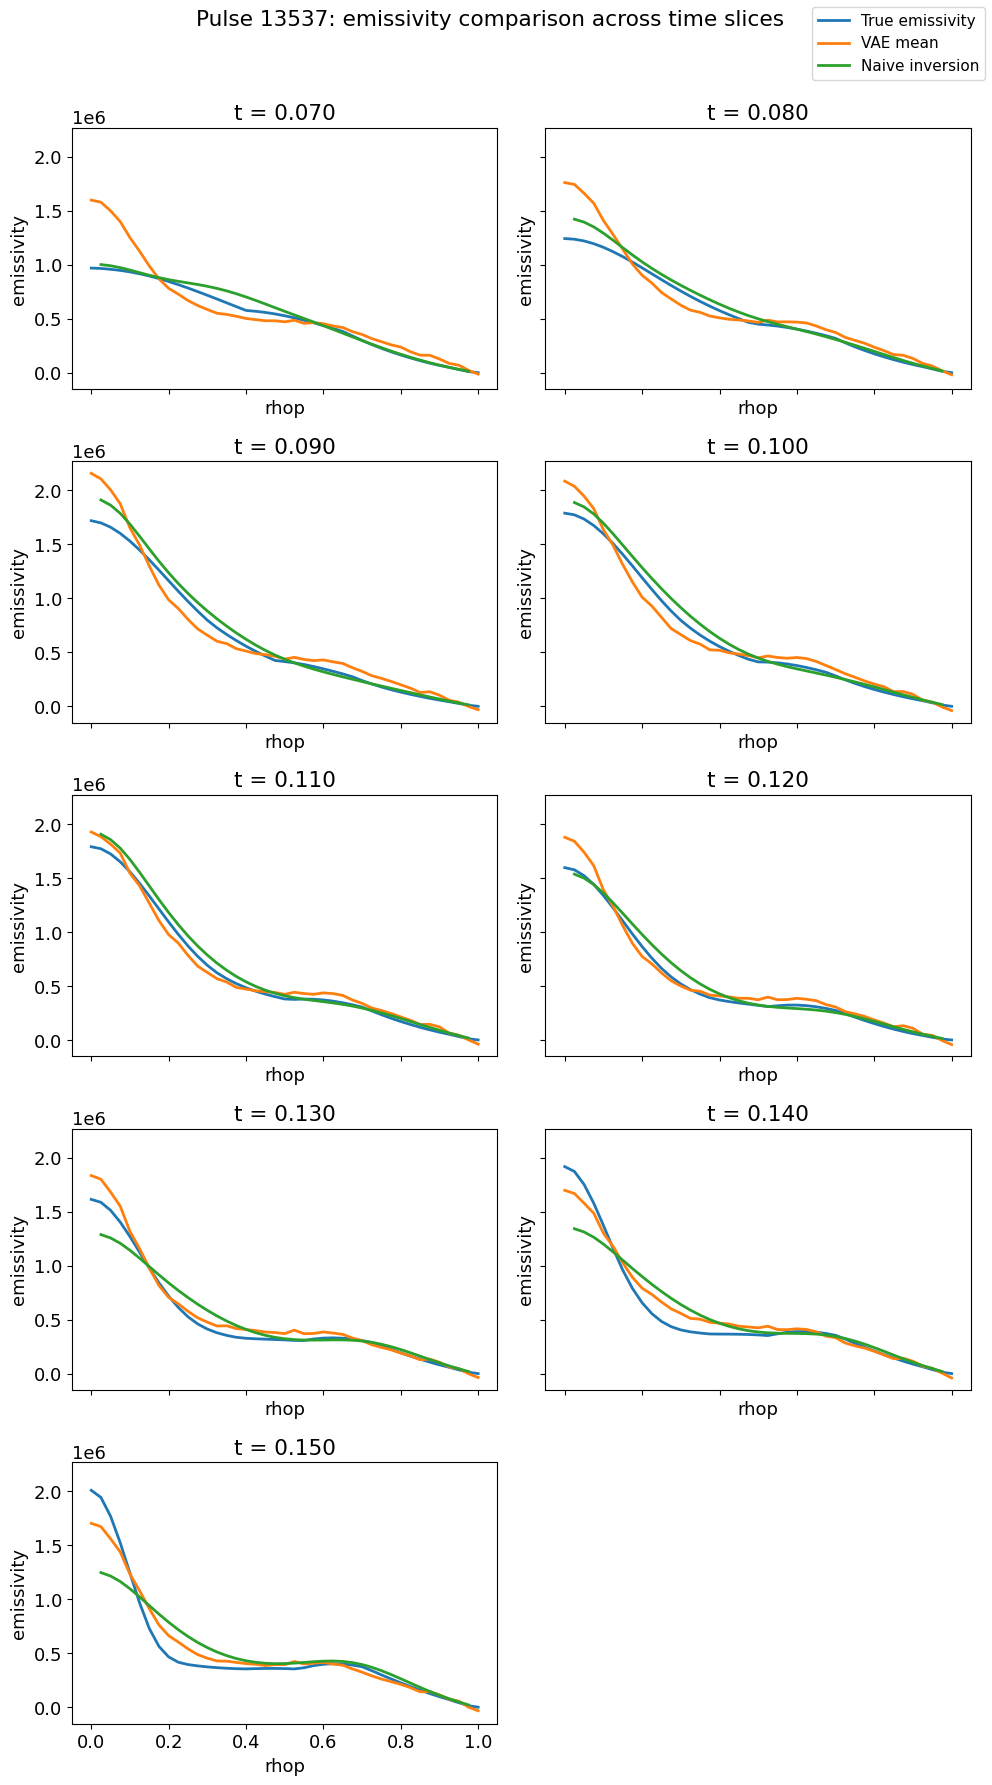

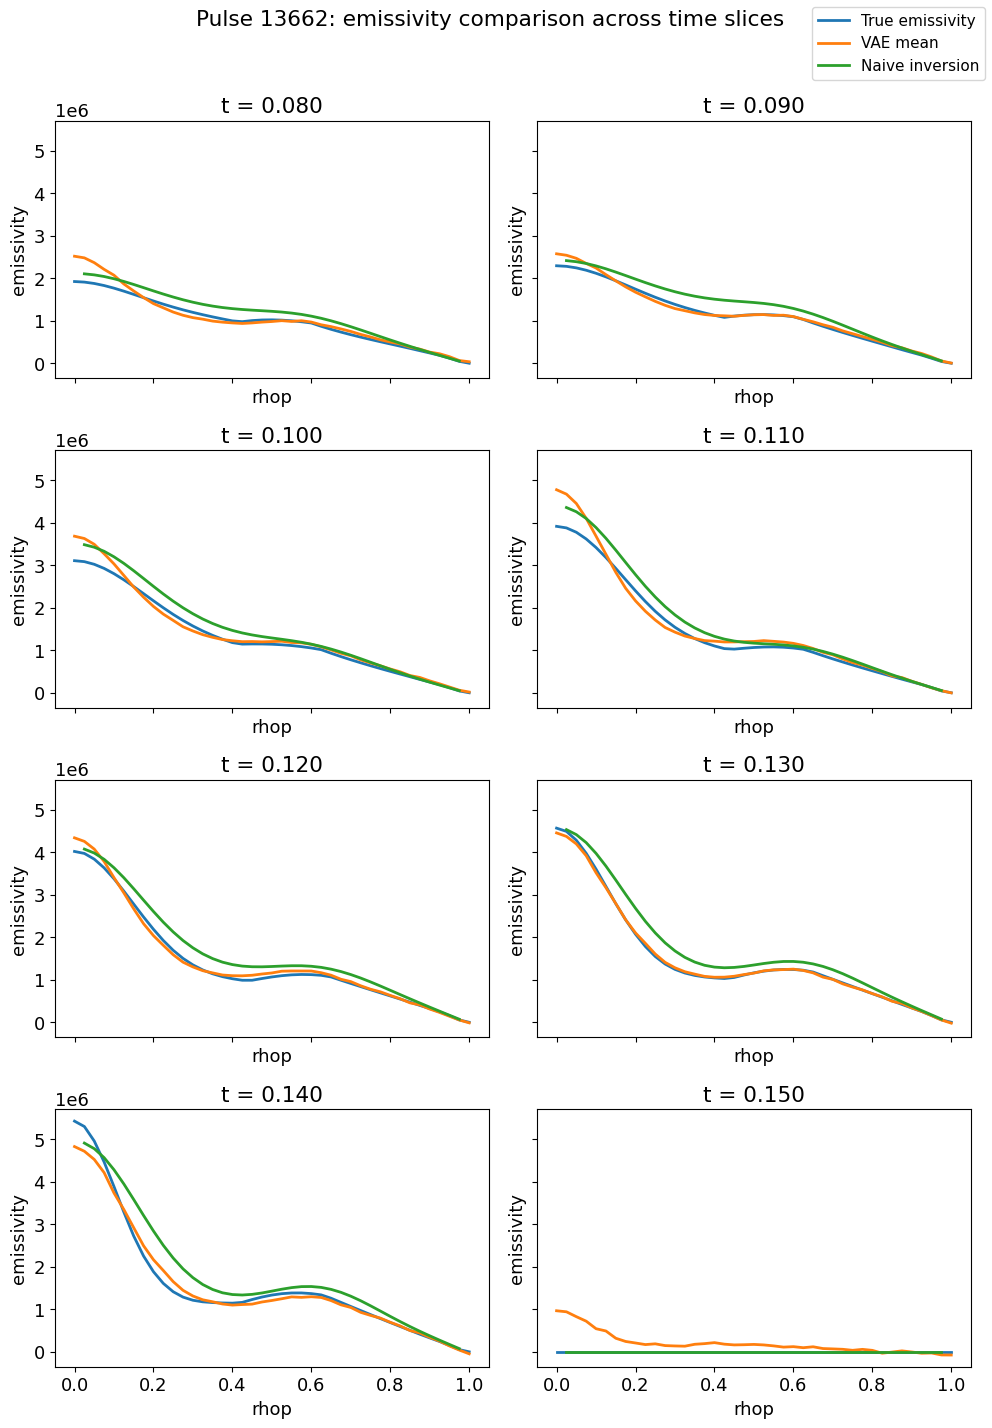

In [42]:
#Tomography inversion vs vae across time slices for a time dependent plasma
from indica.workflows.los_bolometry_radiation import calculate_tomo_inversion

# Dataset stats for normalization
dataset = PairDataset(b_dir, eps_dir)

# Build pulse candidates; we will plot up to three successful pulses.
if 'visualsation_pulses' in globals() and len(visualsation_pulses) > 0:
    pulse_candidates = list(visualsation_pulses)
elif 'filtered_pulses' in globals() and len(filtered_pulses) > 0:
    pulse_candidates = [(int(p), None) for p in filtered_pulses[:20]]
elif dataset.best_pulse is not None:
    pulse_candidates = [(int(dataset.best_pulse), None)]
else:
    raise ValueError('No pulse available for visualization. Run the real-data cells first.')

max_pulses_to_plot = 3
use_all_timepoints_plot = True
min_valid_channels_required = 1

plotted_pulses = 0
for pulse_spec in pulse_candidates:
    if plotted_pulses >= max_pulses_to_plot:
        break

    if isinstance(pulse_spec, (tuple, list)):
        selected_pulse = int(pulse_spec[0])
        selected_time = pulse_spec[1] if len(pulse_spec) > 1 else None
    else:
        selected_pulse = int(pulse_spec)
        selected_time = None

    try:
        model_pulse = build_real_model_for_pulse(selected_pulse)
        bckc, emissivity_tmp = model_pulse(return_emissivity=True)
        brightness = bckc['brightness']
    except Exception as exc:
        print(f'Skipping pulse {selected_pulse}: model build/run failed: {exc}')
        continue

    print(f'Using pulse {selected_pulse}')
    print('emissivity shape:', emissivity_tmp.shape)
    print('brightness shape:', brightness.shape)

    if use_all_timepoints_plot:
        t_candidates = np.arange(brightness.sizes['t'], dtype=int)
    else:
        if selected_time is not None:
            t_values = np.asarray(brightness.t.values, dtype=float)
            t_candidates = np.array([int(np.argmin(np.abs(t_values - float(selected_time))))], dtype=int)
        else:
            t_candidates = np.array([np.random.randint(brightness.sizes['t'])], dtype=int)

    # Pre-filter by tomography channel validity rule on this pulse/time-series
    # (finite and strictly > 0 channels).
    valid_channels_per_t = np.sum(
        np.isfinite(brightness.values) & (brightness.values > 0.0),
        axis=1,
    )
    t_indices = np.array(
        [ti for ti in t_candidates if valid_channels_per_t[ti] >= min_valid_channels_required],
        dtype=int,
    )
    print('Candidate time indices:', t_candidates.tolist())
    print('Valid channels per t:', valid_channels_per_t.tolist())
    print('Kept time indices for tomography:', t_indices.tolist())

    if len(t_indices) == 0:
        print(f'Skipping pulse {selected_pulse}: no valid times for tomography')
        continue

    # Compute tomography one timeslice at a time to avoid group-wise channel invalidation.
    tomo_profiles = []
    used_t_indices = []
    failed_t_indices = []
    for ti in t_indices:
        try:
            tomo_single = calculate_tomo_inversion(
                brightness.isel(t=[ti]),
                model_pulse.transform,
                emissivity_tmp.rhop,
            )
            tomo_profiles.append(tomo_single.isel(t=0).values)
            used_t_indices.append(int(ti))
        except Exception as exc:
            failed_t_indices.append((int(ti), str(exc)))

    if len(used_t_indices) == 0:
        print(f'Skipping pulse {selected_pulse}: tomography failed at all selected times')
        if len(failed_t_indices) > 0:
            print(f'  First failure: {failed_t_indices[0][1]}')
        continue

    if len(failed_t_indices) > 0:
        print('Skipped failing times (index, reason):')
        for ti_fail, msg in failed_t_indices[:5]:
            print(f'  t_idx={ti_fail}: {msg}')

    used_t_indices = np.array(used_t_indices, dtype=int)

    # Plot comparisons for this pulse (one figure per pulse)
    if len(used_t_indices) == 1:
        fig, axes = plt.subplots(1, 1, figsize=(6, 4))
        axes = np.array([axes])
    else:
        n_cols = 2
        n_rows = int(np.ceil(len(used_t_indices) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3.5 * n_rows), sharex=True, sharey=True)
        axes = np.atleast_1d(axes).ravel()

    for ax in axes[len(used_t_indices):]:
        ax.axis('off')

    for ax, ti, e_tomo in zip(axes[:len(used_t_indices)], used_t_indices, tomo_profiles):
        e_true = emissivity_tmp.isel(t=ti).values

        # VAE: normalize brightness, sample K, decode, then unnormalize emissivity
        b_t = brightness.isel(t=ti).values.astype(np.float32)
        b_t_norm = (b_t - dataset.mu_b) / dataset.sigma_b
        b_t_norm = torch.from_numpy(b_t_norm).unsqueeze(0)

        K = 20
        latent_dim = vaemodel.fc3m.out_features
        z = torch.randn(K, latent_dim)
        b_rep = b_t_norm.expand(K, -1)
        with torch.no_grad():
            e_samps = vaemodel.decode(b_rep, z)
            e_samps_un = e_samps * dataset.sigma_eps + dataset.mu_eps
            e_vae = e_samps_un.mean(dim=0).cpu().numpy()

        ax.plot(emissivity_tmp.rhop, e_true, label='True emissivity')
        ax.plot(emissivity_tmp.rhop, e_vae, label='VAE mean')
        ax.plot(emissivity_tmp.rhop, e_tomo, label='Naive inversion')
        ax.set_title(f't = {float(brightness.t.values[ti]):.3f}')
        ax.set_xlabel('rhop')
        ax.set_ylabel('emissivity')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right')
    fig.suptitle(f'Pulse {selected_pulse}: emissivity comparison across time slices', y=1.02)
    fig.tight_layout()

    plotted_pulses += 1

print(f'Plotted {plotted_pulses} pulse(s).')


no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
no profile params given so updating all


Text(0.02, 0.98, 'VAE wins: 62.0%\nmedian Δ=51176.4297')

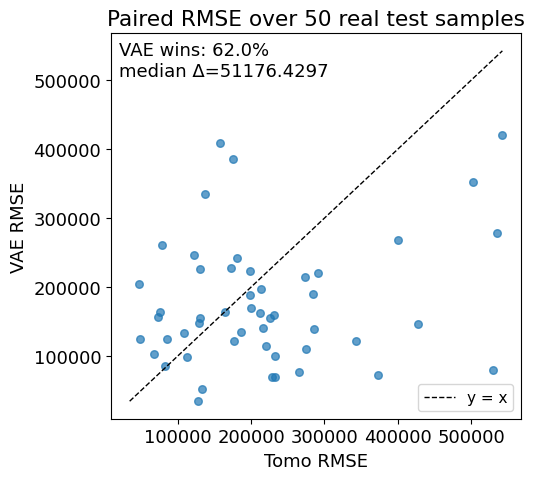

In [47]:
# Compare VAE vs 1D tomography on test-set samples from real pulse/time slices

import csv
import numpy as np
import torch

K = 50
min_valid_channels_required = 4
max_test_samples = 50  # e.g. set to 100 for a quick run

# Resolve base dataset and test indices from earlier split
if 'testsplit' in globals() and hasattr(testsplit, 'indices') and hasattr(testsplit, 'dataset'):
    test_indices = list(testsplit.indices)
    base_dataset = testsplit.dataset
elif 'test_dataloader' in globals() and hasattr(test_dataloader, 'dataset') and hasattr(test_dataloader.dataset, 'indices') and hasattr(test_dataloader.dataset, 'dataset'):
    test_indices = list(test_dataloader.dataset.indices)
    base_dataset = test_dataloader.dataset.dataset
else:
    raise ValueError('Could not find testsplit/test_dataloader subset. Run the dataset split cell first.')

if max_test_samples is not None:
    test_indices = test_indices[: int(max_test_samples)]

if 'meta_dir' not in globals():
    raise ValueError('meta_dir is required to map test samples to real (pulse, time).')

with open(meta_dir, newline='') as f:
    rows = list(csv.reader(f))
has_header = bool(rows) and rows[0] == ['pulse', 'time_s']
meta_rows = rows[1:] if has_header else rows
if len(meta_rows) != len(base_dataset):
    raise ValueError(
        f'meta_dir row count ({len(meta_rows)}) does not match dataset length ({len(base_dataset)}). '
        'Rebuild aligned data/meta first.'
    )

dataset = PairDataset(b_dir, eps_dir)
latent_dim = vaemodel.fc3m.out_features

vae_rmse = []
tomo_rmse = []

n_attempted = 0
n_skipped_invalid_channels = 0
n_skipped_tomo_failure = 0
n_skipped_bad_meta = 0

pulse_cache = {}

def load_real_pulse_bundle(pulse):
    pulse = int(pulse)
    if pulse not in pulse_cache:
        model_pulse = build_real_model_for_pulse(pulse)
        bckc, emissivity = model_pulse(return_emissivity=True)
        pulse_cache[pulse] = dict(
            model=model_pulse,
            brightness=bckc['brightness'],
            emissivity=emissivity,
        )
    return pulse_cache[pulse]

for idx in test_indices:
    n_attempted += 1

    try:
        pulse = int(float(meta_rows[idx][0]))
        t_target = float(meta_rows[idx][1])
    except Exception:
        n_skipped_bad_meta += 1
        continue

    try:
        pulse_bundle = load_real_pulse_bundle(pulse)
    except Exception as exc:
        print(f'Skipping test idx {idx} (pulse {pulse}): failed to load pulse: {exc}')
        n_skipped_tomo_failure += 1
        continue

    model_pulse = pulse_bundle['model']
    measurements = pulse_bundle['brightness']
    emissivity = pulse_bundle['emissivity']

    t_values = np.asarray(measurements.t.values, dtype=float)
    if t_values.size == 0:
        n_skipped_tomo_failure += 1
        continue
    t_idx = int(np.argmin(np.abs(t_values - t_target)))

    b_t = measurements.isel(t=t_idx).values.astype(np.float32)
    if np.sum(np.isfinite(b_t) & (b_t > 0.0)) < min_valid_channels_required:
        n_skipped_invalid_channels += 1
        continue

    e_true = emissivity.isel(t=t_idx).values.astype(np.float32)

    try:
        tomo_single = calculate_tomo_inversion(
            measurements.isel(t=[t_idx]),
            model_pulse.transform,
            emissivity.rhop,
        )
        e_tomo = tomo_single.isel(t=0).values.astype(np.float32)
    except Exception:
        n_skipped_tomo_failure += 1
        continue

    # VAE inversion
    b_t_norm = (b_t - dataset.mu_b) / dataset.sigma_b
    b_t_norm = torch.from_numpy(b_t_norm).unsqueeze(0)

    z = torch.randn(K, latent_dim)
    b_rep = b_t_norm.expand(K, -1)
    with torch.no_grad():
        e_samps = vaemodel.decode(b_rep, z)
        e_samps_un = e_samps * dataset.sigma_eps + dataset.mu_eps
        e_vae = e_samps_un.mean(dim=0).cpu().numpy()

    # Filter NaNs and compute RMSE on valid points only
    valid = np.isfinite(e_tomo) & np.isfinite(e_true) & np.isfinite(e_vae)
    if not np.any(valid):
        n_skipped_tomo_failure += 1
        continue

    e_true_v = e_true[valid]
    e_tomo_v = e_tomo[valid]
    e_vae_v = e_vae[valid]

    vae_rmse.append(np.sqrt(np.mean((e_vae_v - e_true_v) ** 2)))
    tomo_rmse.append(np.sqrt(np.mean((e_tomo_v - e_true_v) ** 2)))

vae_rmse = np.array(vae_rmse)
tomo_rmse = np.array(tomo_rmse)

if len(vae_rmse) == 0:
    raise ValueError(
        'No valid test samples remained after filtering/tomography. '
        f'Attempted={n_attempted}, bad_meta={n_skipped_bad_meta}, invalid_channels={n_skipped_invalid_channels}, tomo_fail={n_skipped_tomo_failure}'
    )

print(f'Attempted test samples: {n_attempted}')
print(f'Used samples: {len(vae_rmse)}')
print(f'Skipped bad meta: {n_skipped_bad_meta}')
print(f'Skipped invalid channels: {n_skipped_invalid_channels}')
print(f'Skipped tomo failures: {n_skipped_tomo_failure}')
print(f'Unique pulses loaded: {len(pulse_cache)}')
print(f'VAE RMSE:  mean={vae_rmse.mean():.4f}  std={vae_rmse.std():.4f}')
print(f'Tomo RMSE: mean={tomo_rmse.mean():.4f}  std={tomo_rmse.std():.4f}')

# Paired scatter with y=x line
plt.figure(figsize=(5.5, 5))
plt.scatter(tomo_rmse, vae_rmse, alpha=0.7, s=30)
mn = min(tomo_rmse.min(), vae_rmse.min())
mx = max(tomo_rmse.max(), vae_rmse.max())
plt.plot([mn, mx], [mn, mx], 'k--', linewidth=1, label='y = x')
plt.xlabel('Tomo RMSE')
plt.ylabel('VAE RMSE')
plt.title(f'Paired RMSE over {len(vae_rmse)} real test samples')
plt.legend()
plt.tight_layout()

delta = tomo_rmse - vae_rmse
win_rate = 100.0 * np.mean(delta > 0)
plt.gca().text(
    0.02,
    0.98,
    f'VAE wins: {win_rate:.1f}%\nmedian Δ={np.median(delta):.4f}',
    transform=plt.gca().transAxes,
    va='top',
)


no profile params given so updating all
no profile params given so updating all
no profile params given so updating all
Plotted 3 pulse figure(s): [13509, 13537, 13662]


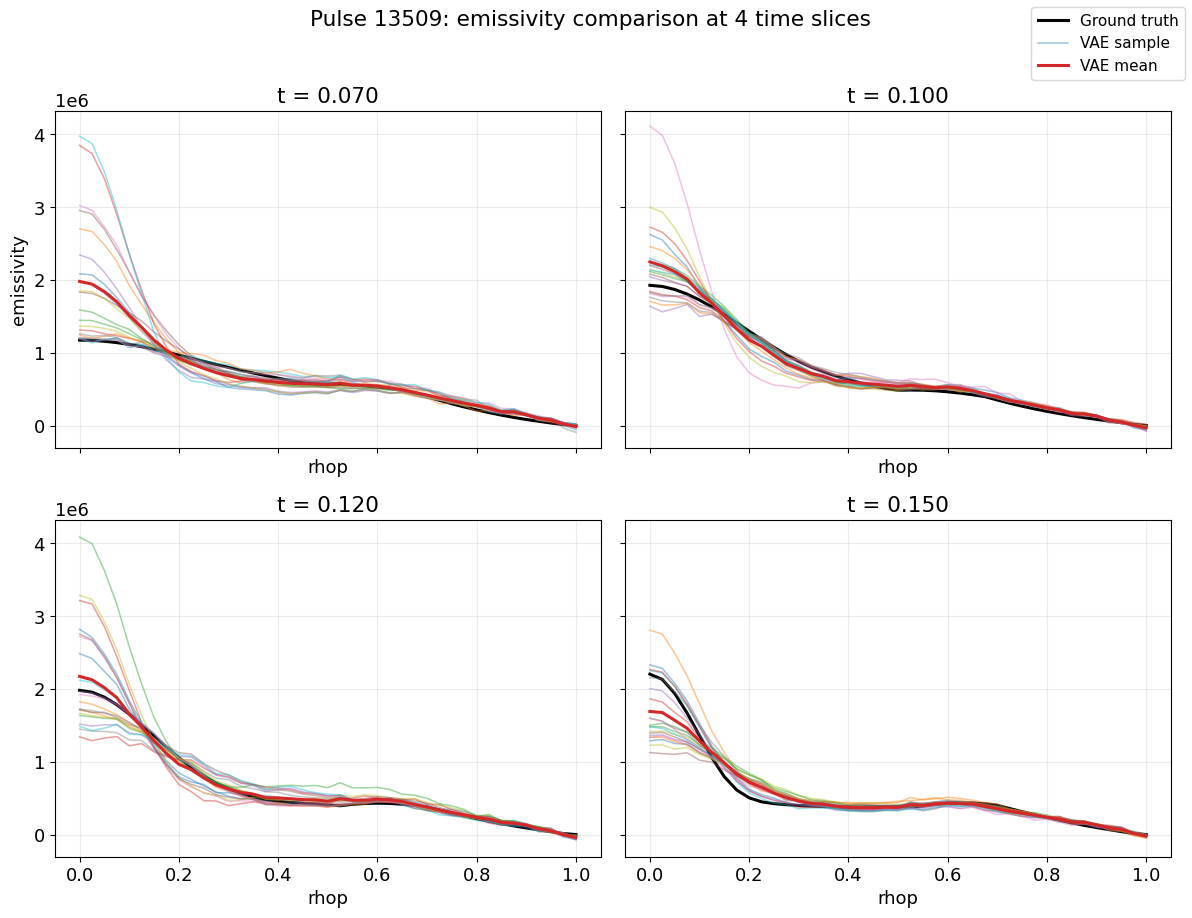

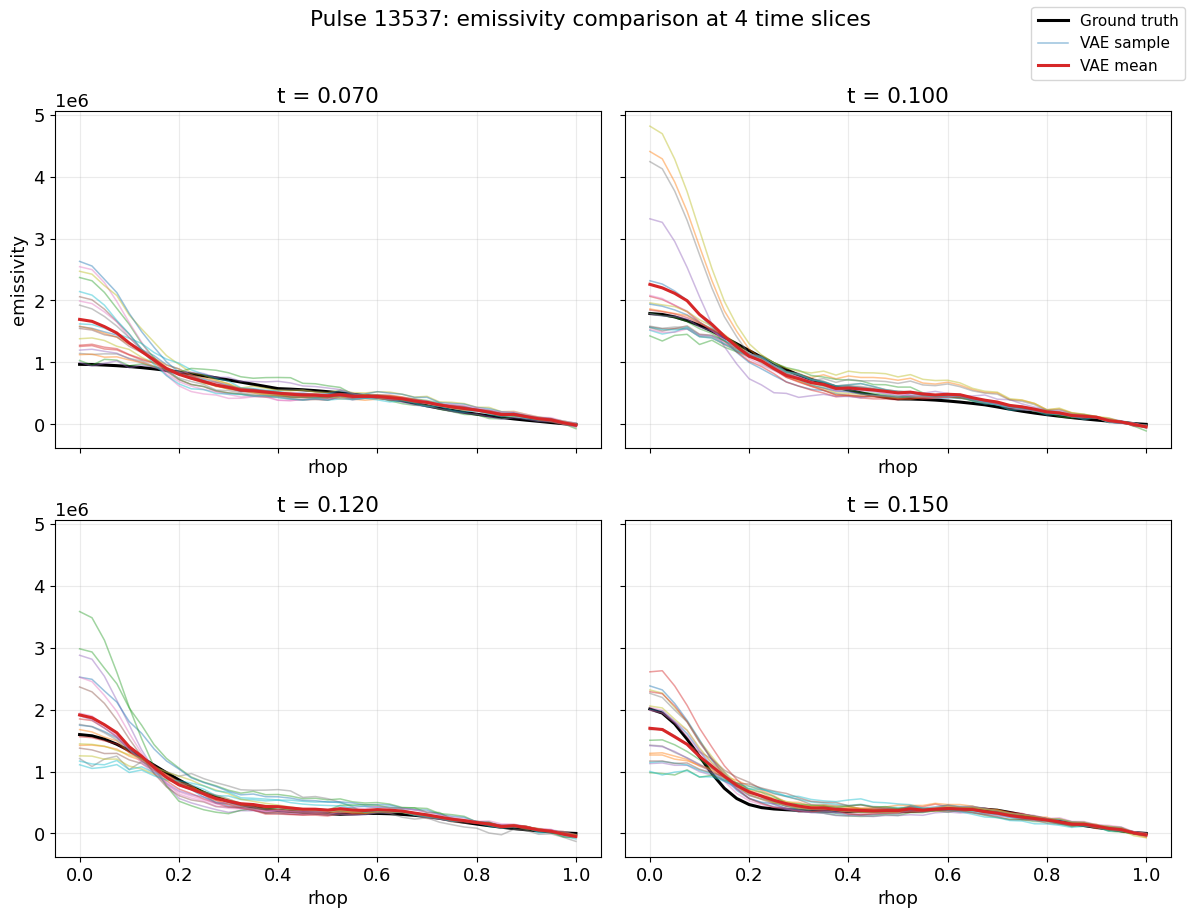

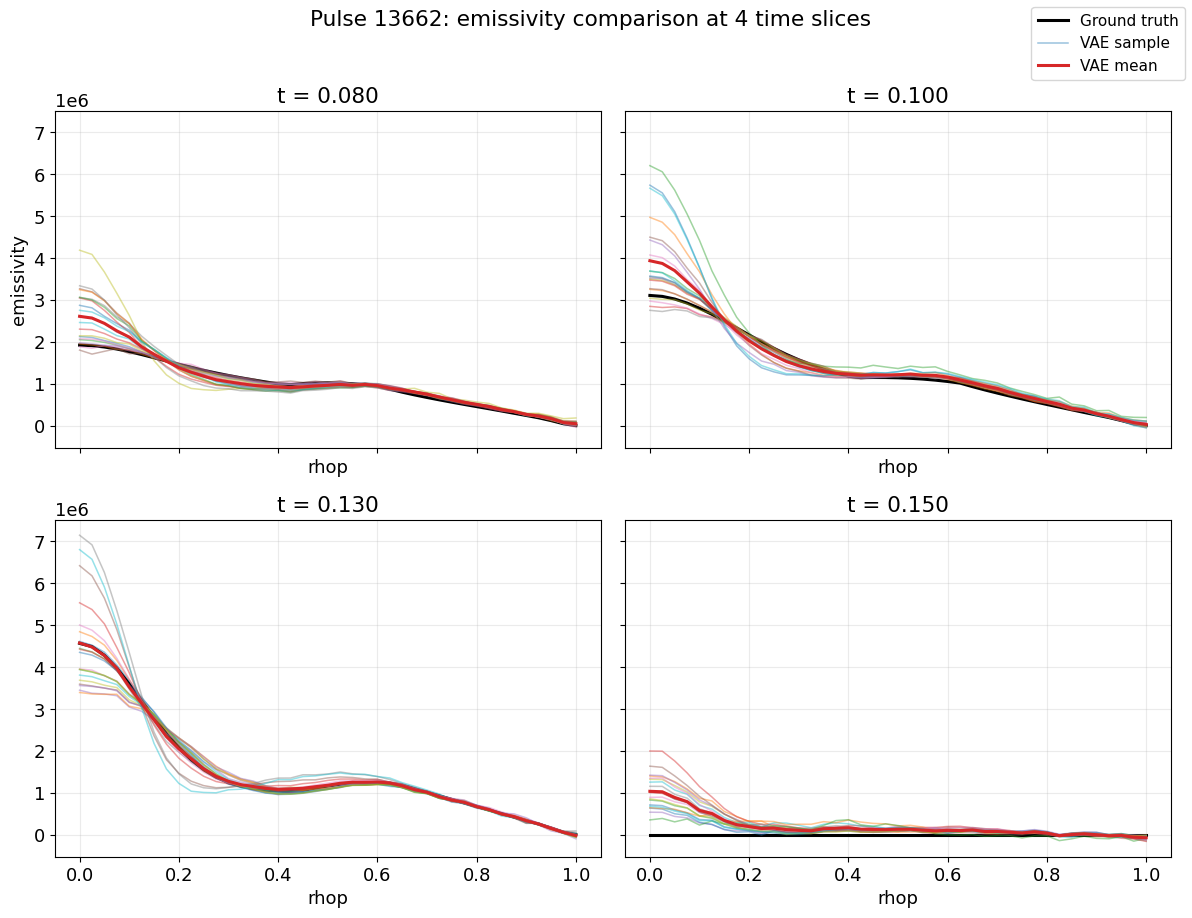

In [51]:
# Emissivity comparison with VAE samples on real pulses (3 pulses x 4 time slices)

import numpy as np
import torch
import matplotlib.pyplot as plt

dataset = PairDataset(b_dir, eps_dir)
latent_dim = vaemodel.fc3m.out_features

n_pulses_to_plot = 3
n_times_per_pulse = 4
n_samples = 20
min_valid_channels_required = 3

if 'visualsation_pulses' in globals() and len(visualsation_pulses) > 0:
    pulse_candidates = [int(p[0]) if isinstance(p, (tuple, list)) else int(p) for p in visualsation_pulses]
elif 'filtered_pulses' in globals() and len(filtered_pulses) > 0:
    pulse_candidates = [int(p) for p in filtered_pulses]
elif 'dataset' in globals() and hasattr(dataset, 'best_pulse') and dataset.best_pulse is not None:
    pulse_candidates = [int(dataset.best_pulse)]
else:
    raise ValueError('No pulse candidates found. Run the real-data cells first.')

# Keep first unique pulses in candidate order
pulse_candidates = list(dict.fromkeys(pulse_candidates))

def choose_time_indices(valid_t_indices, n_pick):
    valid_t_indices = np.asarray(valid_t_indices, dtype=int)
    if valid_t_indices.size == 0:
        return valid_t_indices
    if valid_t_indices.size <= n_pick:
        return valid_t_indices
    pos = np.linspace(0, valid_t_indices.size - 1, n_pick)
    idx = np.round(pos).astype(int)
    idx = np.clip(idx, 0, valid_t_indices.size - 1)
    idx = np.unique(idx)
    chosen = valid_t_indices[idx]
    if chosen.size < n_pick:
        for ti in valid_t_indices:
            if ti not in chosen:
                chosen = np.append(chosen, ti)
            if chosen.size == n_pick:
                break
    return np.asarray(chosen[:n_pick], dtype=int)

pulse_cache_viz = {}
plotted = 0

for pulse in pulse_candidates:
    if plotted >= n_pulses_to_plot:
        break

    try:
        model_pulse = build_real_model_for_pulse(int(pulse))
        bckc, emissivity_tmp = model_pulse(return_emissivity=True)
        brightness = bckc['brightness']
    except Exception as exc:
        print(f'Skipping pulse {pulse}: failed to build/run model: {exc}')
        continue

    valid_counts = np.sum(np.isfinite(brightness.values) & (brightness.values > 0.0), axis=1)
    valid_t = np.where(valid_counts >= min_valid_channels_required)[0]
    t_plot_indices = choose_time_indices(valid_t, n_times_per_pulse)

    if t_plot_indices.size == 0:
        print(f'Skipping pulse {pulse}: no valid time slices')
        continue

    pulse_cache_viz[int(pulse)] = dict(
        model=model_pulse,
        brightness=brightness,
        emissivity=emissivity_tmp,
        t_indices=t_plot_indices,
    )

    n_show = int(t_plot_indices.size)
    n_cols = 2
    n_rows = int(np.ceil(n_show / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4.5 * n_rows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for ax in axes[n_show:]:
        ax.axis('off')

    for ax, t_idx in zip(axes[:n_show], t_plot_indices):
        e_true = emissivity_tmp.isel(t=t_idx).values.astype(np.float32)
        b_t = brightness.isel(t=t_idx).values.astype(np.float32)
        b_t_norm = torch.from_numpy((b_t - dataset.mu_b) / dataset.sigma_b).unsqueeze(0)

        with torch.no_grad():
            z = torch.randn(n_samples, latent_dim)
            b_rep = b_t_norm.expand(n_samples, -1)
            e_samps = vaemodel.decode(b_rep, z)
            e_samps_un = (e_samps * dataset.sigma_eps + dataset.mu_eps).cpu().numpy()

        e_vae_mean = e_samps_un.mean(axis=0)

        ax.plot(emissivity_tmp.rhop, e_true, color='k', linewidth=2.2, label='Ground truth')
        for i in range(n_samples):
            label = 'VAE sample' if i == 0 else None
            ax.plot(emissivity_tmp.rhop, e_samps_un[i], alpha=0.45, linewidth=1.1, label=label)
        ax.plot(emissivity_tmp.rhop, e_vae_mean, color='tab:red', linewidth=2.2, label='VAE mean')
        ax.set_title(f't = {float(brightness.t.values[t_idx]):.3f}')
        ax.set_xlabel('rhop')
        ax.grid(alpha=0.25)

    axes[0].set_ylabel('emissivity')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right')
    fig.suptitle(f'Pulse {pulse}: emissivity comparison at {n_show} time slices', y=1.02)
    fig.tight_layout()

    plotted += 1

selected_pulses_for_viz = list(pulse_cache_viz.keys())
print(f'Plotted {plotted} pulse figure(s): {selected_pulses_for_viz}')


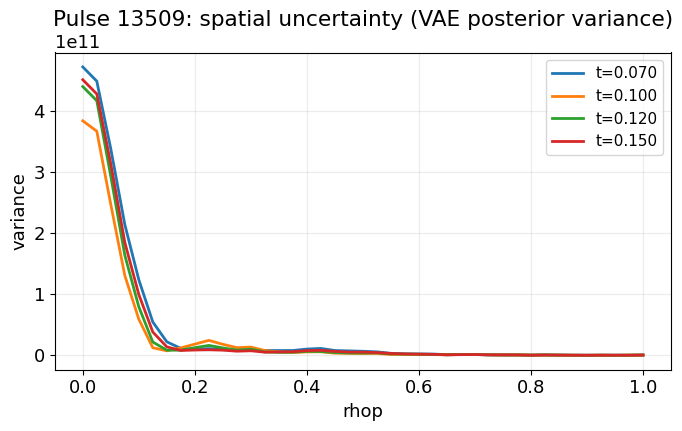

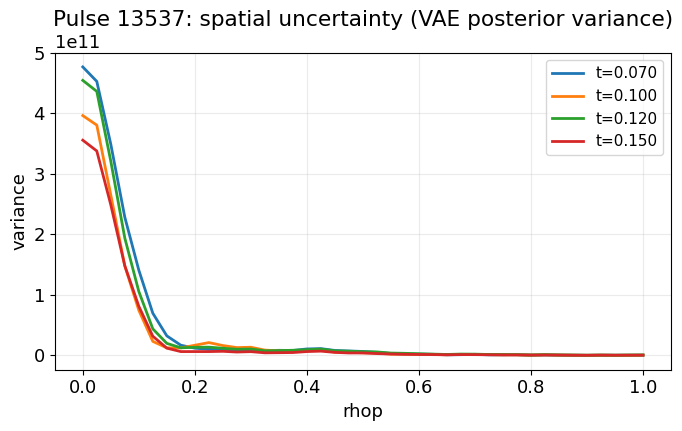

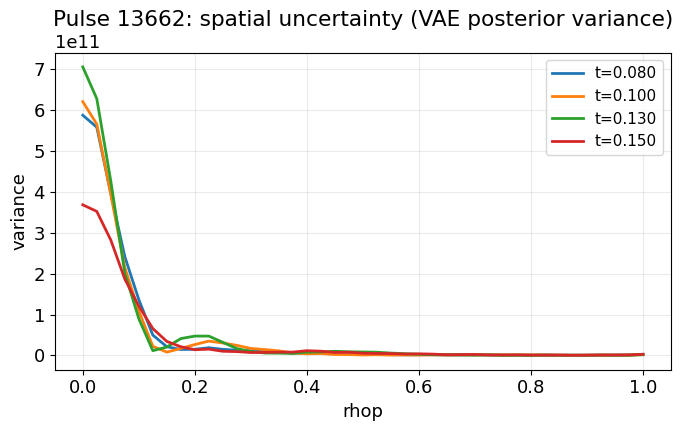

In [52]:
# Spatial uncertainty map on real pulses: posterior variance vs rhop

import numpy as np
import torch
import matplotlib.pyplot as plt

# Reuse pulse/time selection from previous cell when available
if 'pulse_cache_viz' in globals() and len(pulse_cache_viz) > 0:
    pulse_cache_unc = pulse_cache_viz
else:
    pulse_cache_unc = {}
    if 'visualsation_pulses' in globals() and len(visualsation_pulses) > 0:
        pulse_candidates = [int(p[0]) if isinstance(p, (tuple, list)) else int(p) for p in visualsation_pulses]
    elif 'filtered_pulses' in globals() and len(filtered_pulses) > 0:
        pulse_candidates = [int(p) for p in filtered_pulses]
    elif 'dataset' in globals() and hasattr(dataset, 'best_pulse') and dataset.best_pulse is not None:
        pulse_candidates = [int(dataset.best_pulse)]
    else:
        raise ValueError('No pulse candidates found. Run the real-data cells first.')

    pulse_candidates = list(dict.fromkeys(pulse_candidates))[:3]
    for pulse in pulse_candidates:
        try:
            model_pulse = build_real_model_for_pulse(int(pulse))
            bckc, emissivity_tmp = model_pulse(return_emissivity=True)
            brightness = bckc['brightness']
            valid_counts = np.sum(np.isfinite(brightness.values) & (brightness.values > 0.0), axis=1)
            valid_t = np.where(valid_counts >= 1)[0]
            if valid_t.size == 0:
                continue
            if valid_t.size <= 4:
                t_indices = valid_t
            else:
                pick = np.round(np.linspace(0, valid_t.size - 1, 4)).astype(int)
                t_indices = valid_t[np.unique(pick)]
            pulse_cache_unc[int(pulse)] = dict(
                model=model_pulse,
                brightness=brightness,
                emissivity=emissivity_tmp,
                t_indices=np.asarray(t_indices, dtype=int),
            )
        except Exception as exc:
            print(f'Skipping pulse {pulse}: {exc}')

if len(pulse_cache_unc) == 0:
    raise ValueError('No real pulse data available for uncertainty plotting.')

n_samples = 200
latent_dim = vaemodel.fc3m.out_features

for pulse, bundle in pulse_cache_unc.items():
    brightness = bundle['brightness']
    emissivity_tmp = bundle['emissivity']
    t_indices = np.asarray(bundle['t_indices'], dtype=int)

    if t_indices.size == 0:
        print(f'Skipping pulse {pulse}: no selected time slices')
        continue

    rhop = np.asarray(emissivity_tmp.rhop.values, dtype=float)
    fig, ax = plt.subplots(figsize=(7, 4.5))

    for t_idx in t_indices:
        t_sel = float(brightness.t.values[t_idx])

        b_t = brightness.isel(t=t_idx).values.astype(np.float32)
        b_t_norm = torch.from_numpy((b_t - dataset.mu_b) / dataset.sigma_b).unsqueeze(0)

        with torch.no_grad():
            z = torch.randn(n_samples, latent_dim)
            b_rep = b_t_norm.expand(n_samples, -1)
            e_samps = vaemodel.decode(b_rep, z)
            e_samps_un = (e_samps * dataset.sigma_eps + dataset.mu_eps).cpu().numpy()

        e_var = e_samps_un.var(axis=0)
        ax.plot(rhop, e_var, linewidth=2, label=f't={t_sel:.3f}')

    ax.set_xlabel('rhop')
    ax.set_ylabel('variance')
    ax.set_title(f'Pulse {pulse}: spatial uncertainty (VAE posterior variance)')
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()


Sample pool len: 0
no profile params given so updating all
Sample pool len: 1
no profile params given so updating all
Sample pool len: 2
no profile params given so updating all
Sample pool len: 3
no profile params given so updating all
Sample pool len: 4
no profile params given so updating all
Sample pool len: 5
no profile params given so updating all
Sample pool len: 6
no profile params given so updating all
Sample pool len: 7
no profile params given so updating all
Sample pool len: 8
no profile params given so updating all
Sample pool len: 9
no profile params given so updating all
Sample pool len: 10
Sample pool len: 11
no profile params given so updating all
Sample pool len: 12
no profile params given so updating all
Sample pool len: 13
no profile params given so updating all
Sample pool len: 14
no profile params given so updating all
Sample pool len: 15
no profile params given so updating all
Sample pool len: 16
no profile params given so updating all
Sample pool len: 17
no profile

/tmp/ipykernel_2779945/3315511266.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([t_tomo_ms, t_vae_ms], labels=['1D tomo', 'VAE'], showfliers=True)


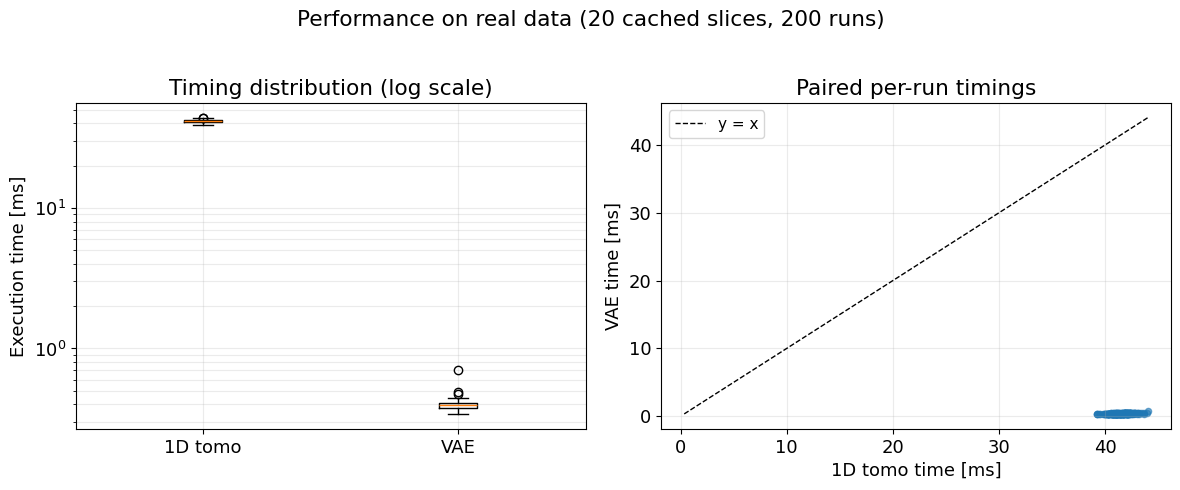

In [58]:
# Performance benchmark: 1D tomography inversion vs VAE inference on real-like data

import csv
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

# Benchmark settings
n_runs = 200
warmup_runs = 10
K_perf = 32
max_pool_samples = 20
min_valid_channels_required = 2
seed = 0

rng = np.random.default_rng(seed)
dataset_perf = PairDataset(b_dir, eps_dir)
latent_dim = vaemodel.fc3m.out_features

# Prefer test-set indices for realistic held-out evaluation
if 'testsplit' in globals() and hasattr(testsplit, 'indices'):
    candidate_indices = list(testsplit.indices)
elif 'test_dataloader' in globals() and hasattr(test_dataloader, 'dataset') and hasattr(test_dataloader.dataset, 'indices'):
    candidate_indices = list(test_dataloader.dataset.indices)
else:
    candidate_indices = list(range(len(dataset_perf)))

if 'meta_dir' not in globals():
    raise ValueError('meta_dir is required for real-like benchmarking. Run multi-pulse data generation first.')

with open(meta_dir, newline='') as f:
    rows = list(csv.reader(f))
has_header = bool(rows) and rows[0] == ['pulse', 'time_s']
meta_rows = rows[1:] if has_header else rows

if len(meta_rows) != len(dataset_perf):
    raise ValueError(
        f'meta_dir row count ({len(meta_rows)}) != dataset length ({len(dataset_perf)}). '
        'Rebuild aligned CSV/meta first.'
    )

rng.shuffle(candidate_indices)

pulse_cache_perf = {}

def load_pulse_bundle_perf(pulse):
    pulse = int(pulse)
    if pulse not in pulse_cache_perf:
        model_pulse = build_real_model_for_pulse(pulse)
        bckc, emissivity = model_pulse(return_emissivity=True)
        pulse_cache_perf[pulse] = dict(
            model=model_pulse,
            brightness=bckc['brightness'],
            emissivity=emissivity,
        )
    return pulse_cache_perf[pulse]

sample_pool = []
skipped_bad_meta = 0
skipped_load_fail = 0
skipped_invalid_channels = 0
skipped_tomo_unstable = 0

for idx in candidate_indices:
    print(f"Sample pool len: {len(sample_pool)}")
    if len(sample_pool) >= max_pool_samples:
        break

    try:
        pulse = int(float(meta_rows[idx][0]))
        t_target = float(meta_rows[idx][1])
    except Exception:
        skipped_bad_meta += 1
        continue

    try:
        bundle = load_pulse_bundle_perf(pulse)
    except Exception:
        skipped_load_fail += 1
        continue

    measurements = bundle['brightness']
    emissivity = bundle['emissivity']
    transform = bundle['model'].transform

    t_values = np.asarray(measurements.t.values, dtype=float)
    if t_values.size == 0:
        skipped_load_fail += 1
        continue

    t_idx = int(np.argmin(np.abs(t_values - t_target)))
    b_vec = measurements.isel(t=t_idx).values.astype(np.float32)

    n_valid = int(np.sum(np.isfinite(b_vec) & (b_vec > 0.0)))
    if n_valid < min_valid_channels_required:
        skipped_invalid_channels += 1
        continue

    brightness_sel = measurements.isel(t=[t_idx])

    # Pre-check tomography stability so benchmark loop is cleanly paired.
    try:
        _ = calculate_tomo_inversion(brightness_sel, transform, emissivity.rhop)
    except Exception:
        skipped_tomo_unstable += 1
        continue

    sample_pool.append(
        dict(
            idx=int(idx),
            pulse=int(pulse),
            t_idx=int(t_idx),
            b_vec=b_vec,
            brightness_sel=brightness_sel,
            transform=transform,
            rhop=emissivity.rhop,
        )
    )

if len(sample_pool) == 0:
    raise ValueError(
        'No stable real-like samples available for benchmarking. '
        f'skipped_bad_meta={skipped_bad_meta}, skipped_load_fail={skipped_load_fail}, '
        f'skipped_invalid_channels={skipped_invalid_channels}, skipped_tomo_unstable={skipped_tomo_unstable}'
    )

print(f'Prepared sample pool: {len(sample_pool)} slices from {len(pulse_cache_perf)} pulses')
print(f'Skipped bad meta rows: {skipped_bad_meta}')
print(f'Skipped load failures: {skipped_load_fail}')
print(f'Skipped invalid-channel slices: {skipped_invalid_channels}')
print(f'Skipped tomo-unstable slices: {skipped_tomo_unstable}')

def run_tomo(sample):
    _ = calculate_tomo_inversion(sample['brightness_sel'], sample['transform'], sample['rhop'])

def run_vae(sample):
    b_t_norm = torch.from_numpy((sample['b_vec'] - dataset_perf.mu_b) / dataset_perf.sigma_b).unsqueeze(0)
    z = torch.randn(K_perf, latent_dim)
    b_rep = b_t_norm.expand(K_perf, -1)
    with torch.no_grad():
        e_samps = vaemodel.decode(b_rep, z)
        _ = (e_samps * dataset_perf.sigma_eps + dataset_perf.mu_eps).mean(dim=0)

# Warm-up
for i in range(min(warmup_runs, len(sample_pool))):
    s = sample_pool[i]
    run_tomo(s)
    run_vae(s)

t_tomo = []
t_vae = []

for r in range(n_runs):
    s = sample_pool[r % len(sample_pool)]

    t0 = time.perf_counter()
    run_tomo(s)
    t_tomo.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    run_vae(s)
    t_vae.append(time.perf_counter() - t0)

t_tomo_ms = np.asarray(t_tomo) * 1e3
t_vae_ms = np.asarray(t_vae) * 1e3
speedup = t_tomo_ms / np.maximum(t_vae_ms, 1e-9)

print(f'Runs: {n_runs}')
print(f'1D tomo  mean={t_tomo_ms.mean():.2f} ms  median={np.median(t_tomo_ms):.2f} ms  p95={np.percentile(t_tomo_ms,95):.2f} ms')
print(f'VAE inf. mean={t_vae_ms.mean():.2f} ms  median={np.median(t_vae_ms):.2f} ms  p95={np.percentile(t_vae_ms,95):.2f} ms')
print(f'Speedup (tomo/vae): mean={speedup.mean():.2f}x  median={np.median(speedup):.2f}x')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].boxplot([t_tomo_ms, t_vae_ms], labels=['1D tomo', 'VAE'], showfliers=True)
axes[0].set_yscale('log')
axes[0].set_ylabel('Execution time [ms]')
axes[0].set_title('Timing distribution (log scale)')
axes[0].grid(alpha=0.25, which='both')

axes[1].scatter(t_tomo_ms, t_vae_ms, alpha=0.6, s=20)
mn = float(min(t_tomo_ms.min(), t_vae_ms.min()))
mx = float(max(t_tomo_ms.max(), t_vae_ms.max()))
axes[1].plot([mn, mx], [mn, mx], 'k--', linewidth=1, label='y = x')
axes[1].set_xlabel('1D tomo time [ms]')
axes[1].set_ylabel('VAE time [ms]')
axes[1].set_title('Paired per-run timings')
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.suptitle(f'Performance on real data ({len(sample_pool)} cached slices, {n_runs} runs)', y=1.02)
fig.tight_layout()
